In [2]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

load_dotenv()

SUPABASE_URL = os.getenv("SUPABASE_URL")

if not SUPABASE_URL:
    raise ValueError("SUPABASE_URL is not set in the environment variables.")

connection_string = (SUPABASE_URL)

try:
    engine = create_engine(connection_string) 
    print("✅ Successfully connected to Supabase PostgreSQL.")
except Exception as e:
    print(f"❌ Connection failed: {e}")

✅ Successfully connected to Supabase PostgreSQL.


In [3]:
import pandas as pd

In [4]:
customers_df = pd.read_sql(
    "SELECT * FROM gold.dim_customers;",
    engine
)

customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP
1,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG
2,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES
3,0002414f95344307404f0ace7a26f1d5,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG
4,000379cdec625522490c315e70c7a9fb,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP


In [5]:
products_df = pd.read_sql(
    "SELECT * FROM gold.dim_products;",
    engine
)

products_df.head()

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,bf5d132b4d30a18970b8ee7798725af1,moveis_cozinha_area_de_servico_jantar_e_jardim,10800.0,35.0,65.0,35.0
1,0b01ff8012c6301714339a530e7f9879,beleza_saude,750.0,27.0,9.0,18.0
2,0bff7ada15fd3840490f79b2612db33b,papelaria,1775.0,39.0,22.0,22.0
3,7808e6dbab3a59c8a918adc4d6e12776,esporte_lazer,500.0,34.0,16.0,16.0
4,2c1559e64bc92171b52fdaea272cbf39,casa_construcao,750.0,23.0,27.0,27.0


In [6]:
sellers_df = pd.read_sql(
    "SELECT * FROM gold.dim_sellers;",
    engine
)

sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,117cfc326c6d50da67ca858ff5c0c852,25530,sao joao de meriti,RJ
1,3a734b715d333a2588a3d54a0c9b8746,6132,osasco,SP
2,ac137bac82ffa8548e62bd9d01d2a14f,3631,sao paulo,SP
3,5a425cc503b39b262a847fd6212bf53b,86010,londrina,PR
4,717b78b0950b51ed00b1471d858b0edc,18220,alambari,SP


In [7]:
date_df = pd.read_sql(
    "SELECT * FROM gold.dim_date;",
    engine
)

date_df.head()

,date_id,year,month,day,month_name
0,2016-09-04,2016.0,9.0,4.0,September
1,2016-09-05,2016.0,9.0,5.0,September
2,2016-09-13,2016.0,9.0,13.0,September
3,2016-09-15,2016.0,9.0,15.0,September
4,2016-10-03,2016.0,10.0,3.0,October


In [8]:
orders_df = pd.read_sql(
    "SELECT * FROM gold.fact_orders;",
    engine
)

orders_df.head()

,order_id,customer_id,order_status,order_date,order_delivered_customer_date,order_estimated_delivery_date
0,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26,2017-05-12 16:04:24,2017-05-15
1,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14,2018-01-22 13:19:16,2018-02-05
2,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08,2018-08-14 13:32:39,2018-08-20
3,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04,2017-03-01 16:42:31,2017-03-17
4,00048cc3ae777c65dbb7d2a0634bc1ea,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15,2017-05-22 13:44:35,2017-06-06


In [9]:
order_items_df = pd.read_sql(
    "SELECT * FROM gold.fact_order_items;",
    engine
)

order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [10]:
payments_df = pd.read_sql(
    "SELECT * FROM gold.fact_payments;",
    engine
)

payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [11]:
reviews_df = pd.read_sql(
    "SELECT * FROM gold.fact_reviews;",
    engine
)

reviews_df.head()

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
0,0001239bc1de2e33cb583967c2ca4c67,fc046d7776171871436844218f817d7d,5,2018-03-20,2018-03-20 18:36:04
1,0001cc6860aeaf5b9017fe4131a52e62,d4665434b01caa9dc3e3e78b3eb3593e,5,2018-06-22,2018-06-26 13:51:29
2,00020c7512a52e92212f12d3e37513c0,e28abf2eb2f1fbcbdc2dd0cd9a561671,5,2018-04-25,2018-04-26 14:55:36
3,00032b0141443497c898b3093690af51,04fb47576993a3cb0c12d4b25eab6e4e,5,2017-05-30,2017-06-01 23:28:55
4,00034d88989f9a4c393bdcaec301537f,5f358d797a49fe2f24352f73426215f6,5,2017-08-12,2017-08-13 19:56:53


# EDA Starts

# 1. Executive Business Overview

Company Scorecard (single pane)

In [14]:
df = (
    orders_df
    .merge(order_items_df, on="order_id", how="left")
    .merge(payments_df, on="order_id", how="left")
    .merge(reviews_df, on="order_id", how="left")
)

df = (df
      .merge(customers_df, on="customer_id", how="left"))

In [15]:
df.head()

,order_id,customer_id,order_status,order_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,...,payment_installments,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26,2017-05-12 16:04:24,2017-05-15,1.0,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,...,3.0,259.83,7b07bacd811c4117b742569b04ce3580,4.0,2017-05-13,2017-05-15 11:34:13,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
1,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14,2018-01-22 13:19:16,2018-02-05,1.0,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,...,5.0,216.87,0c5b33dea94867d1ac402749e5438e8b,5.0,2018-01-23,2018-01-23 16:06:31,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
2,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08,2018-08-14 13:32:39,2018-08-20,1.0,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,...,2.0,25.78,f4028d019cb58564807486a6aaf33817,4.0,2018-08-15,2018-08-15 16:39:01,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
3,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04,2017-03-01 16:42:31,2017-03-17,1.0,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,...,3.0,218.04,940144190dcba6351888cafa43f3a3a5,5.0,2017-03-02,2017-03-03 10:54:59,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP
4,00048cc3ae777c65dbb7d2a0634bc1ea,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15,2017-05-22 13:44:35,2017-06-06,1.0,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,...,1.0,34.59,5e4e50af3b7960b7a10d86ec869509e8,4.0,2017-05-23,2017-05-24 19:00:09,85c835d128beae5b4ce8602c491bf385,38017,uberaba,MG


## EDA

# Company Scorecard (single pane)

In [31]:
# ==========================
# BUSINESS KPI CALCULATIONS
# ==========================

total_installments = df["payment_installments"].sum()
total_payment = df["payment_value"].sum()

total_orders = df["order_id"].nunique()
aov = total_payment / total_orders

active_customers = df["customer_id"].nunique()
active_sellers = df["seller_id"].nunique()
avg_review_score = df["review_score"].mean()

# Convert to datetime
df["order_delivered_customer_date"] = pd.to_datetime(
    df["order_delivered_customer_date"]
)

df["order_estimated_delivery_date"] = pd.to_datetime(
    df["order_estimated_delivery_date"]
)

delivered_orders = df.dropna(
    subset=["order_delivered_customer_date"]
)

on_time = (
    delivered_orders["order_delivered_customer_date"]
    <= delivered_orders["order_estimated_delivery_date"]
).sum()

late_orders = (
    delivered_orders["order_delivered_customer_date"]
    > delivered_orders["order_estimated_delivery_date"]
).sum()

total_delivered = len(delivered_orders)
on_time_percentage = (on_time / total_delivered) * 100

# ==========================
# KPI DASHBOARD
# ==========================

print("=" * 60)
print("How is the business doing, right now?")
print("=" * 60)

print("\n💰 REVENUE METRICS")
print("-" * 60)
print(f"Total Revenue (Payments)      : BRL {total_payment:,.2f}")
print(f"Revenue (Millions)            : BRL {total_payment/1_000_000:,.2f} M")
print(f"Total Installments            : {total_installments:,}")
print(f"Average Order Value (AOV)     : BRL {aov:,.2f}")

print("\n🛒 ORDER METRICS")
print("-" * 60)
print(f"Total Orders                  : {total_orders:,}")
print(f"Delivered Orders              : {total_delivered:,}")
print(f"Late Orders                   : {late_orders:,}")

print("\n👥 CUSTOMER & SELLER METRICS")
print("-" * 60)
print(f"Active Customers              : {active_customers:,}")
print(f"Active Sellers                : {active_sellers:,}")

print("\n⭐ CUSTOMER EXPERIENCE")
print("-" * 60)
print(f"Average Review Score          : {avg_review_score:.2f} / 5")
print(f"On-Time Delivery Rate         : {on_time_percentage:.2f}%")

print("\n" + "=" * 60)
print("✅ KPI Calculation Complete")
print("=" * 60)

How is the business doing, right now?

💰 REVENUE METRICS
------------------------------------------------------------
Total Revenue (Payments)      : BRL 15,090,444.32
Revenue (Millions)            : BRL 15.09 M
Total Installments            : 257,019.0
Average Order Value (AOV)     : BRL 206.07

🛒 ORDER METRICS
------------------------------------------------------------
Total Orders                  : 73,231
Delivered Orders              : 84,801
Late Orders                   : 6,625

👥 CUSTOMER & SELLER METRICS
------------------------------------------------------------
Active Customers              : 73,231
Active Sellers                : 2,919

⭐ CUSTOMER EXPERIENCE
------------------------------------------------------------
Average Review Score          : 4.02 / 5
On-Time Delivery Rate         : 92.19%

✅ KPI Calculation Complete


# Revenue & Order Growth Trend

In [34]:
df = (
    orders_df
    .merge(order_items_df, on="order_id", how="left")
    .merge(date_df, left_on="order_date", right_on="date_id", how="left")
)

df.head()

,order_id,customer_id,order_status,order_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,date_id,year,month,day,month_name
0,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26,2017-05-12 16:04:24,2017-05-15,1.0,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-04-26,2017.0,4.0,26.0,April
1,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14,2018-01-22 13:19:16,2018-02-05,1.0,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-14,2018.0,1.0,14.0,January
2,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08,2018-08-14 13:32:39,2018-08-20,1.0,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-08,2018.0,8.0,8.0,August
3,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04,2017-03-01 16:42:31,2017-03-17,1.0,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-04,2017.0,2.0,4.0,February
4,00048cc3ae777c65dbb7d2a0634bc1ea,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15,2017-05-22 13:44:35,2017-06-06,1.0,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69,2017-05-15,2017.0,5.0,15.0,May


In [37]:
df.info

<bound method DataFrame.info of                                order_id                       customer_id  \
0      00018f77f2f0320c557190d7a144bdd3  f6dd3ec061db4e3987629fe6b26e5cce   
1      000229ec398224ef6ca0657da4fc703e  6489ae5e4333f3693df5ad4372dab6d3   
2      00024acbcdf0a6daa1e931b038114c75  d4eb9395c8c0431ee92fce09860c5a06   
3      00042b26cf59d7ce69dfabb4e55b4fd9  58dbd0b2d70206bf40e62cd34e84d795   
4      00048cc3ae777c65dbb7d2a0634bc1ea  816cbea969fe5b689b39cfc97a506742   
...                                 ...                               ...   
83458  fffb9224b6fc7c43ebb0904318b10b5f  4d3abb73ceb86353aeadbe698aa9d5cb   
83459  fffcd46ef2263f404302a634eb57f7eb  84c5d4fbaf120aae381fad077416eaa0   
83460  fffce4705a9662cd70adb13d4a31832d  29309aa813182aaddc9b259e31b870e6   
83461  fffe18544ffabc95dfada21779c9644f  b5e6afd5a41800fdf401e0272ca74655   
83462  fffe41c64501cc87c801fd61db3f6244  96d649da0cc4ff33bb408b199d4c7dcf   

      order_status  order_date order_delive

In [50]:
df["order_date"] = pd.to_datetime(df["order_date"])

monthly = (
    df.groupby(df["order_date"].dt.to_period("M"))
      .agg(
          Product_Revenue=("price", "sum"),
          Freight_Revenue=("freight_value", "sum"),
          Total_Orders=("order_id", "nunique")
      )
)

# Total Revenue = Product Revenue + Freight Revenue
monthly["Total_Revenue"] = (
    monthly["Product_Revenue"] + monthly["Freight_Revenue"]
)

monthly = (
    monthly.drop(columns=["Product_Revenue", "Freight_Revenue"])
           .reset_index()
)

monthly["Month"] = monthly["order_date"].astype(str)
monthly.drop(columns="order_date", inplace=True)

# Month-over-Month Growth
monthly["MoM Revenue Growth (%)"] = (
    monthly["Total_Revenue"]
    .pct_change()
    .mul(100)
    .round(2)
)

monthly["MoM Order Growth (%)"] = (
    monthly["Total_Orders"]
    .pct_change()
    .mul(100)
    .round(2)
)

# Format numbers for presentation
monthly_display = monthly.copy()

monthly_display["Total_Revenue"] = monthly_display["Total_Revenue"].map(
    lambda x: f"BRL {x:,.2f}"
)

monthly_display["Total_Orders"] = monthly_display["Total_Orders"].map(
    "{:,}".format
)

monthly_display["MoM Revenue Growth (%)"] = monthly_display[
    "MoM Revenue Growth (%)"
].map(lambda x: "-" if pd.isna(x) else f"{x:.2f}%")

monthly_display["MoM Order Growth (%)"] = monthly_display[
    "MoM Order Growth (%)"
].map(lambda x: "-" if pd.isna(x) else f"{x:.2f}%")

print("=" * 90)
print("📈 Is the business growing month over month?")
print("=" * 90)
 

📈 Is the business growing month over month?


In [47]:
monthly.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Total_Orders            25 non-null     int64  
 1   Total_Revenue           25 non-null     float64
 2   Month                   25 non-null     str    
 3   MoM Revenue Growth (%)  24 non-null     float64
 4   MoM Order Growth (%)    24 non-null     float64
dtypes: float64(3), int64(1), str(1)
memory usage: 1.1 KB


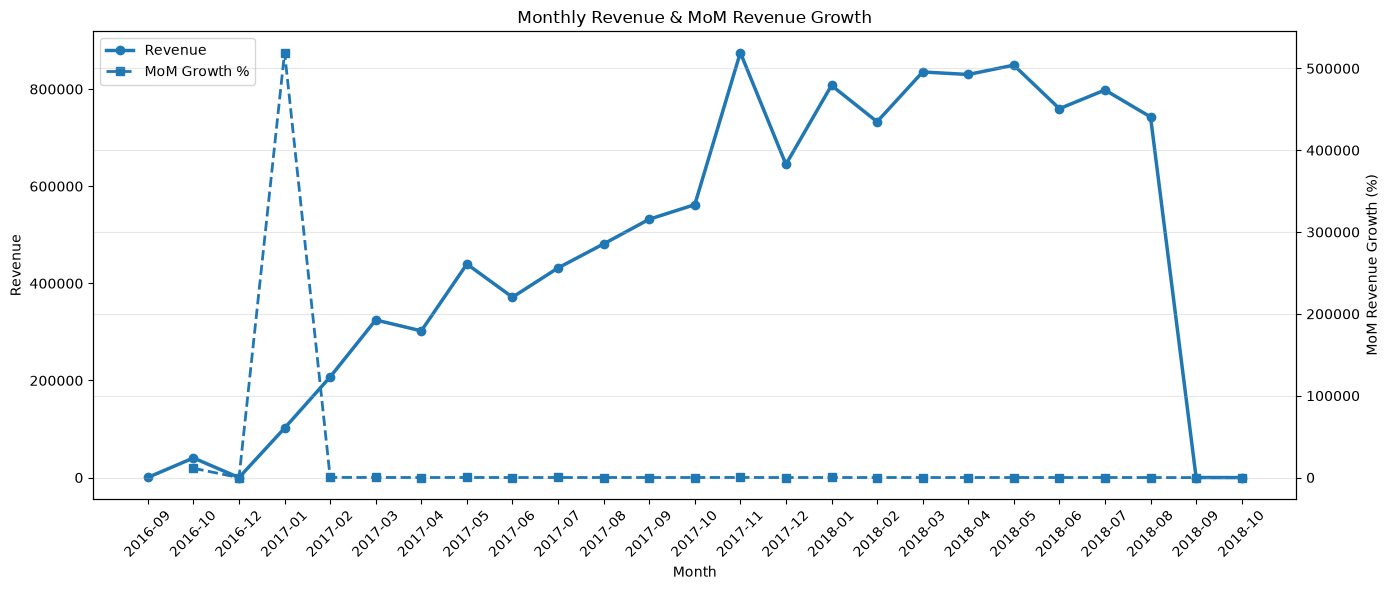

In [48]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14,6))

# Revenue (Left Y-axis)
ax1.plot(
    monthly["Month"],
    monthly["Total_Revenue"],
    marker="o",
    linewidth=2.5,
    label="Revenue"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue")
ax1.tick_params(axis="x", rotation=45)

# Growth % (Right Y-axis)
ax2 = ax1.twinx()

ax2.plot(
    monthly["Month"],
    monthly["MoM Revenue Growth (%)"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="MoM Growth %"
)

ax2.set_ylabel("MoM Revenue Growth (%)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Monthly Revenue & MoM Revenue Growth")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

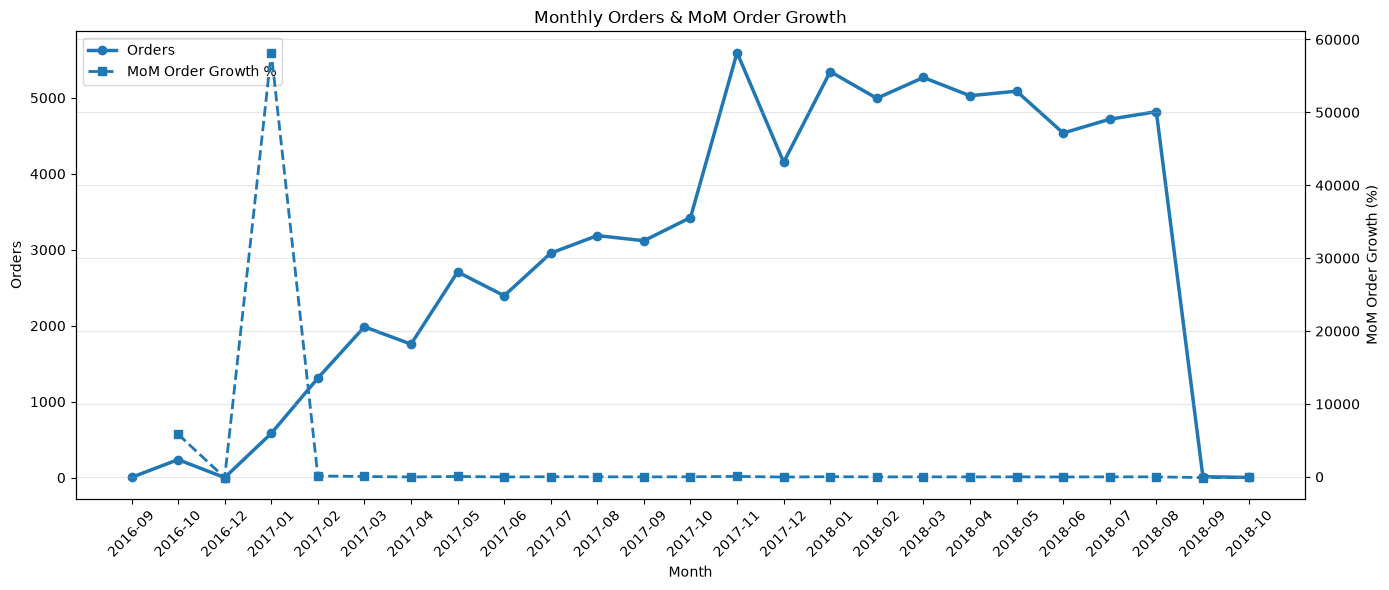

In [49]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14,6))

# Orders
ax1.plot(
    monthly["Month"],
    monthly["Total_Orders"],
    marker="o",
    linewidth=2.5,
    label="Orders"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Orders")
ax1.tick_params(axis="x", rotation=45)

# Growth %
ax2 = ax1.twinx()

ax2.plot(
    monthly["Month"],
    monthly["MoM Order Growth (%)"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="MoM Order Growth %"
)

ax2.set_ylabel("MoM Order Growth (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Monthly Orders & MoM Order Growth")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Delivered vs Cancelled vs Pending Mix

In [57]:
orders_df["status_group"] = orders_df["order_status"].replace({
    "approved": "Pending",
    "created": "Pending",
    "invoiced": "Pending",
    "processing": "Pending",
    "shipped": "Pending",
    "unavailable": "Pending"
})

mix = (
    orders_df["status_group"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Orders")
)

mix["Percentage"] = (
    mix["Orders"] / mix["Orders"].sum() * 100
).round(2)

mix

,Status,Orders,Percentage
0,delivered,71055,97.03
1,Pending,1712,2.34
2,canceled,464,0.63


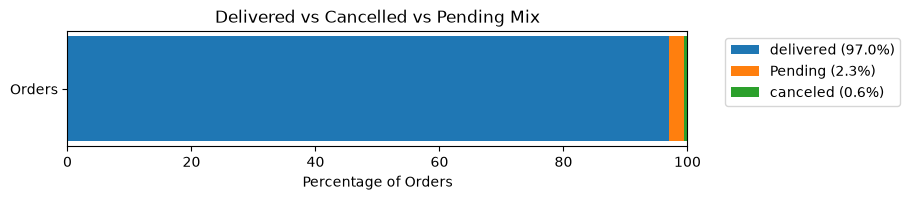

In [58]:
mix_plot = (
    orders_df["status_group"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(8,1.5))

left = 0
for status, pct in mix_plot.items():
    plt.barh(
        y="Orders",
        width=pct,
        left=left,
        label=f"{status} ({pct:.1f}%)"
    )
    left += pct

plt.xlim(0, 100)
plt.xlabel("Percentage of Orders")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.title("Delivered vs Cancelled vs Pending Mix")
plt.show()

# Customer & Seller Base Size Over Time

In [66]:
df = orders_df.merge(
    order_items_df,
    on="order_id",
    how="left"
)

# Revenue per order
order_revenue = (
    df.groupby(["order_id", "order_status"], as_index=False)
      .agg(
          Product_Revenue=("price", "sum"),
          Freight_Revenue=("freight_value", "sum")
      )
)

order_revenue["Total_Revenue"] = (
    order_revenue["Product_Revenue"] +
    order_revenue["Freight_Revenue"]
)

# Summary by Order Status
status_summary = (
    order_revenue.groupby("order_status", as_index=False)
    .agg(
        Total_Orders=("order_id", "count"),
        Total_Revenue=("Total_Revenue", "sum")
    )
)

status_summary["Order Share (%)"] = (
    status_summary["Total_Orders"] /
    status_summary["Total_Orders"].sum() * 100
).round(2)

status_summary["Revenue Share (%)"] = (
    status_summary["Total_Revenue"] /
    status_summary["Total_Revenue"].sum() * 100
).round(2)

status_summary = status_summary.sort_values(
    by="Total_Revenue",
    ascending=False
)

# -------------------------------
# Revenue at Risk
# -------------------------------

revenue_at_risk = status_summary.loc[
    status_summary["order_status"] != "delivered",
    "Total_Revenue"
].sum()

total_revenue = status_summary["Total_Revenue"].sum()

risk_percentage = (
    revenue_at_risk / total_revenue * 100
)

# -------------------------------
# Pretty Display
# -------------------------------

status_display = status_summary.copy()

status_display["Total_Revenue"] = status_display["Total_Revenue"].map(
    lambda x: f"BRL {x:,.2f}"
)

status_display["Total_Orders"] = status_display["Total_Orders"].map(
    "{:,}".format
)

status_display["Order Share (%)"] = status_display["Order Share (%)"].map(
    lambda x: f"{x:.2f}%"
)

status_display["Revenue Share (%)"] = status_display["Revenue Share (%)"].map(
    lambda x: f"{x:.2f}%"
)

print("=" * 90)
print("📦 Is our marketplace supply and demand growing together?")
print("=" * 90)

display(status_display)

print("\n" + "=" * 90)
print("⚠️ BUSINESS RISK SUMMARY")
print("=" * 90)

print(f"💰 Revenue at Risk        : BRL {revenue_at_risk:,.2f}")
print(f"📉 Revenue at Risk (%)    : {risk_percentage:.2f}%")
print(f"💵 Total Revenue          : BRL {total_revenue:,.2f}")

print("=" * 90)

📦 Is our marketplace supply and demand growing together?


,order_status,Total_Orders,Total_Revenue,Order Share (%),Revenue Share (%)
3,delivered,"71,055","BRL 11,353,200.96",97.03%,97.28%
6,shipped,831,"BRL 134,775.93",1.13%,1.15%
1,canceled,464,"BRL 80,905.21",0.63%,0.69%
4,invoiced,216,"BRL 50,495.30",0.29%,0.43%
5,processing,218,"BRL 49,292.45",0.30%,0.42%
7,unavailable,441,"BRL 1,677.55",0.60%,0.01%
0,approved,1,BRL 61.62,0.00%,0.00%
2,created,5,BRL 0.00,0.01%,0.00%



⚠️ BUSINESS RISK SUMMARY
💰 Revenue at Risk        : BRL 317,208.06
📉 Revenue at Risk (%)    : 2.72%
💵 Total Revenue          : BRL 11,670,409.02


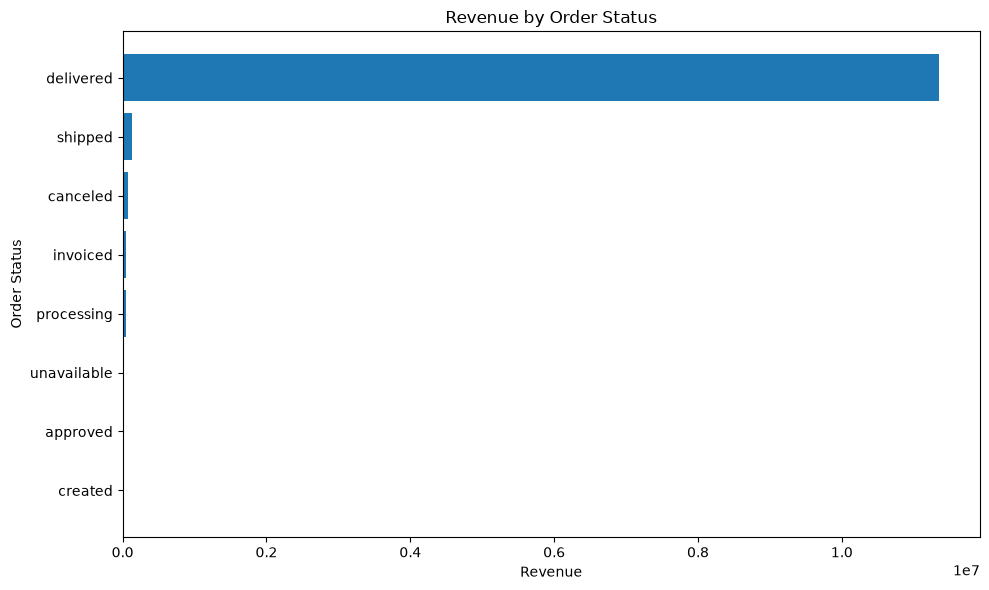

In [63]:
status_summary = status_summary.sort_values("Revenue")

plt.figure(figsize=(10,6))

plt.barh(
    status_summary["order_status"],
    status_summary["Revenue"]
)

plt.title("Revenue by Order Status")
plt.xlabel("Revenue")
plt.ylabel("Order Status")

plt.tight_layout()
plt.show()

# Review Score Health

In [74]:

# =====================================
# CUSTOMER REVIEW ANALYSIS
# =====================================

# Review Distribution
review_dist = (
    reviews_df["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_dist.columns = ["Review Score", "Number of Reviews"]

review_dist["Percentage"] = (
    review_dist["Number of Reviews"]
    / review_dist["Number of Reviews"].sum()
    * 100
).round(2)

# Overall KPIs
avg_score = reviews_df["review_score"].mean()

five_star_reviews = (
    (reviews_df["review_score"] == 5).mean() * 100
)

one_star_reviews = (
    (reviews_df["review_score"] == 1).mean() * 100
)

total_reviews = len(reviews_df)

# Satisfaction Summary
summary = pd.DataFrame({
    "Customer Segment": [
        "😊 Satisfied (4-5)",
        "😐 Neutral (3)",
        "😞 Unsatisfied (1-2)"
    ],
    "Orders": [
        reviews_df["review_score"].isin([4, 5]).sum(),
        (reviews_df["review_score"] == 3).sum(),
        reviews_df["review_score"].isin([1, 2]).sum()
    ]
})

summary["Percentage"] = (
    summary["Orders"] / summary["Orders"].sum() * 100
).round(2)

# =====================================
# DASHBOARD
# =====================================

print("=" * 65)
print("⭐ Are customers happy overall?")
print("=" * 65)

print(f"📝 Total Reviews          : {total_reviews:,}")
print(f"⭐ Average Rating         : {avg_score:.2f} / 5")
print(f"🌟 5-Star Reviews         : {five_star_reviews:.2f}%")
print(f"⚠️ 1-Star Reviews         : {one_star_reviews:.2f}%")

print("\n" + "=" * 65)
print("📊 REVIEW SCORE DISTRIBUTION")
print("=" * 65)

display(review_dist)

print("\n" + "=" * 65)
print("😊 CUSTOMER SATISFACTION SUMMARY")
print("=" * 65)

display(summary)

print("\n" + "=" * 65)
print("✅ Review Analysis Complete")
print("=" * 65)

⭐ Are customers happy overall?
📝 Total Reviews          : 98,410
⭐ Average Rating         : 4.09 / 5
🌟 5-Star Reviews         : 57.83%
⚠️ 1-Star Reviews         : 11.46%

📊 REVIEW SCORE DISTRIBUTION


,Review Score,Number of Reviews,Percentage
0,1,11282,11.46
1,2,3114,3.16
2,3,8097,8.23
3,4,19007,19.31
4,5,56910,57.83



😊 CUSTOMER SATISFACTION SUMMARY


,Customer Segment,Orders,Percentage
0,😊 Satisfied (4-5),75917,77.14
1,😐 Neutral (3),8097,8.23
2,😞 Unsatisfied (1-2),14396,14.63



✅ Review Analysis Complete


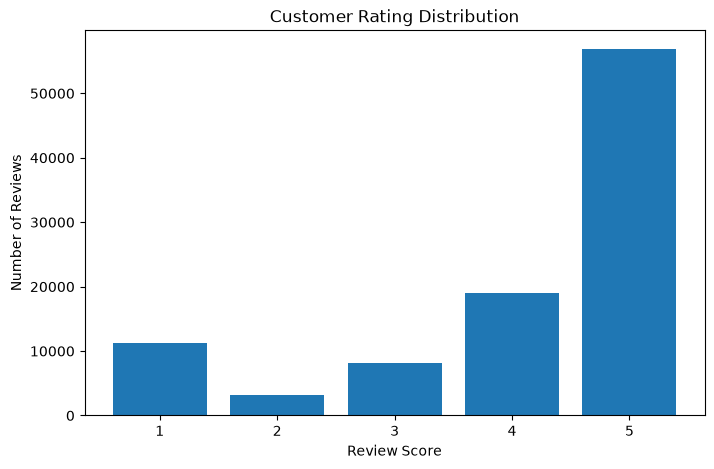

In [75]:
review_dist = (
    reviews_df["review_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    review_dist.index.astype(str),
    review_dist.values
)

plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.title("Customer Rating Distribution")

plt.show()